# 📝 Week 1 – Lab Assignment: Real-World Data Visualisation Challenge

## Setup

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

### 🟡 Task 1: Data Preprocessing

1️⃣ Load the dataset into a Pandas DataFrame.

2️⃣	Select data from a specific country of your choice.

3️⃣	Convert the date column to a datetime format and filter for data from the year 1900 onward.

4️⃣	Handle missing values: Decide on an appropriate strategy (e.g., drop, interpolate, or fill).

5️⃣	Create a new column for the average yearly temperature per country

In [58]:
df = pd.read_csv('GlobalLandTemperaturesByCountry.csv')
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [59]:
# Choose Argentina
data = df[df['Country'] == 'Argentina'].copy()
data

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
25466,1855-05-01,10.745,1.499,Argentina
25467,1855-06-01,6.995,2.073,Argentina
25468,1855-07-01,6.901,1.568,Argentina
25469,1855-08-01,9.097,1.412,Argentina
25470,1855-09-01,11.316,1.384,Argentina
...,...,...,...,...
27362,2013-05-01,11.745,0.166,Argentina
27363,2013-06-01,9.594,0.388,Argentina
27364,2013-07-01,8.344,0.303,Argentina
27365,2013-08-01,9.148,0.302,Argentina


In [60]:
data['dt'] = pd.to_datetime(data['dt'])
data = data[data['dt'].dt.year >= 1900]
data

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
26002,1900-01-01,21.778,0.695,Argentina
26003,1900-02-01,20.960,0.680,Argentina
26004,1900-03-01,17.993,0.386,Argentina
26005,1900-04-01,14.362,0.514,Argentina
26006,1900-05-01,10.847,0.494,Argentina
...,...,...,...,...
27362,2013-05-01,11.745,0.166,Argentina
27363,2013-06-01,9.594,0.388,Argentina
27364,2013-07-01,8.344,0.303,Argentina
27365,2013-08-01,9.148,0.302,Argentina


In [61]:
data['AverageTemperature'] = data['AverageTemperature'].interpolate()

C:\Users\jimmy\AppData\Local\Temp\ipykernel_214052\2853924516.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['AverageTemperature'] = data['AverageTemperature'].interpolate()


In [62]:
data['Year'] = data['dt'].dt.year
yearly_data = data.groupby('Year')['AverageTemperature'].mean().reset_index()

# Display the first few rows to verify
yearly_data.head()

C:\Users\jimmy\AppData\Local\Temp\ipykernel_214052\2795511149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Year'] = data['dt'].dt.year


,Year,AverageTemperature
0,1900,14.807250
1,1901,14.809333
2,1902,14.621167
3,1903,14.376083
4,1904,14.432333


### 🟠 Task 2: Data Visualisation

#### 1️⃣ **Line Chart:** Temperature Trend Over Time  
- 📈 Plot the **yearly average temperature** trend.  
- 🎨 Customise the chart with a **title, axis labels, and markers**.  

#### 2️⃣ **Rolling Average Chart:** 10-Year Rolling Average  
- 📊 Compute and plot **10-year rolling average**.  
- 📈 o	Overlay this rolling average on the original line chart.  

#### 3️⃣ **Compare Multiple Countries:**  
- 🌍 Select **three countries** and compare their trends on the **same chart**.  
- 🟦 Use **different line styles and colours** for each country.  

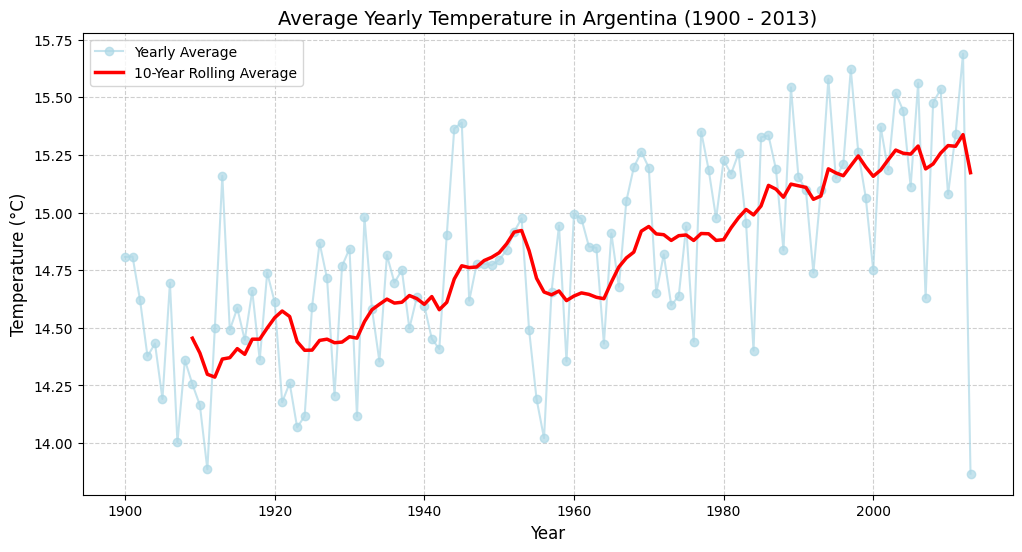

In [63]:
plt.figure(figsize=(12, 6))

# Calculate the 10-year rolling average
yearly_data['10_Year_Rolling_Avg'] = yearly_data['AverageTemperature'].rolling(window=10).mean()

# 1️⃣ Plot the yearly average temperature trend
plt.plot(yearly_data['Year'], yearly_data['AverageTemperature'], 
         marker='o', linestyle='-', color='lightblue', label='Yearly Average', alpha=0.7)

# 2️⃣ Plot the 10-year rolling average
plt.plot(yearly_data['Year'], yearly_data['10_Year_Rolling_Avg'], 
         linestyle='-', color='red', linewidth=2.5, label='10-Year Rolling Average')

# Customise the chart
plt.title('Average Yearly Temperature in Argentina (1900 - 2013)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

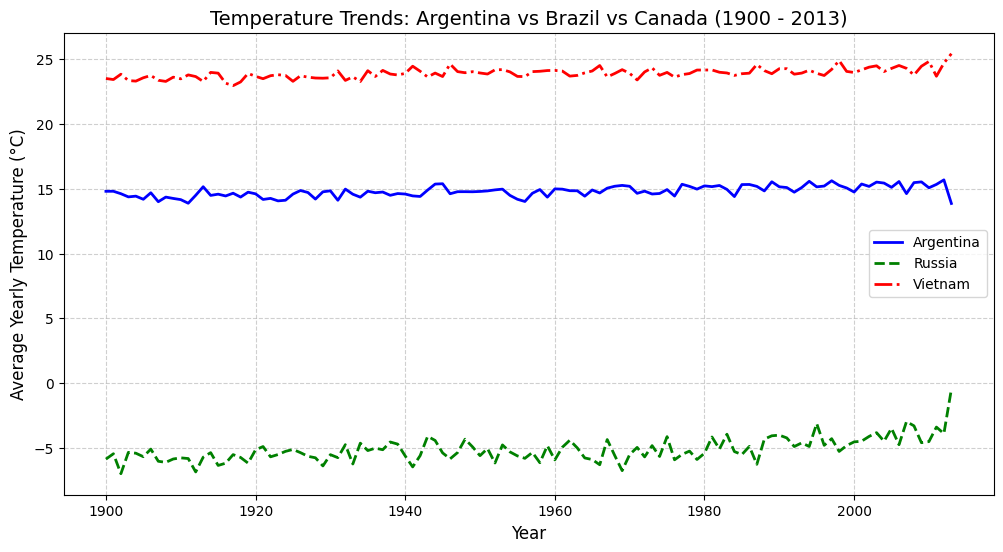

In [64]:
# 3️⃣ Compare Multiple Countries
countries_to_compare = ['Argentina', 'Russia', 'Vietnam']
line_styles = ['-', '--', '-.']
colors = ['blue', 'green', 'red']

plt.figure(figsize=(12, 6))

for i, country in enumerate(countries_to_compare):
    # Filter and preprocess for each country
    c_data = df[df['Country'] == country].copy()
    c_data['dt'] = pd.to_datetime(c_data['dt'])
    c_data = c_data[c_data['dt'].dt.year >= 1900]
    c_data['AverageTemperature'] = c_data['AverageTemperature'].interpolate()
    
    # Calculate yearly average
    c_data['Year'] = c_data['dt'].dt.year
    c_yearly = c_data.groupby('Year')['AverageTemperature'].mean()
    
    # Plot each country's trend
    plt.plot(c_yearly.index, c_yearly.values, 
             linestyle=line_styles[i], color=colors[i], label=country, linewidth=2)

# Customise the chart
plt.title('Temperature Trends: Argentina vs Brazil vs Canada (1900 - 2013)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Yearly Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

### 🟢 Task 3: Extreme Weather Events Analysis

#### 1️⃣ **Identify Top 5 Hottest and Coldest Years:**  

#### 2️⃣	Mark these years on your temperature trend chart witd **annotations**s.  

#### 3️⃣ **Plot Bar Chart:** showing the temperature difference between the hottest and coldest years.  


In [65]:
# 1️⃣ Identify Top 5 Hottest and Coldest Years
top_5_hottest = yearly_data.nlargest(5, 'AverageTemperature')
top_5_coldest = yearly_data.nsmallest(5, 'AverageTemperature')

print("🔥 Top 5 Hottest Years:")
print(top_5_hottest[['Year', 'AverageTemperature']].to_string(index=False))

print("\n❄️ Top 5 Coldest Years:")
print(top_5_coldest[['Year', 'AverageTemperature']].to_string(index=False))

🔥 Top 5 Hottest Years:
 Year  AverageTemperature
 2012           15.689000
 1997           15.620667
 1994           15.578667
 2006           15.561083
 1989           15.543000

❄️ Top 5 Coldest Years:
 Year  AverageTemperature
 2013           13.867222
 1911           13.886333
 1907           14.003333
 1956           14.021417
 1923           14.068083


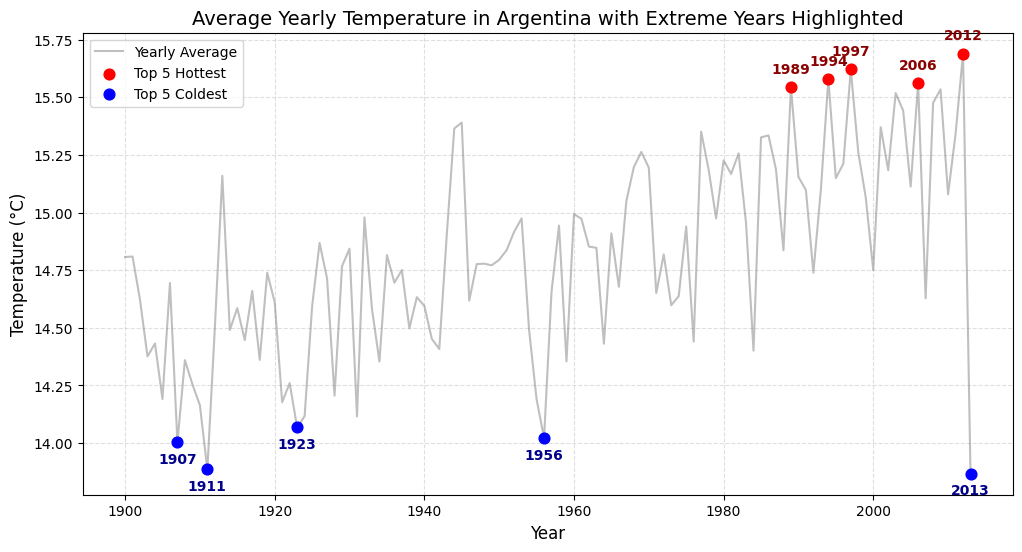

In [66]:
# 2️⃣ Mark these years on your temperature trend chart with annotations
plt.figure(figsize=(12, 6))

# Base line chart
plt.plot(yearly_data['Year'], yearly_data['AverageTemperature'], 
         linestyle='-', color='gray', alpha=0.5, label='Yearly Average')

# Highlight and annotate hottest years
plt.scatter(top_5_hottest['Year'], top_5_hottest['AverageTemperature'], 
            color='red', zorder=5, s=60, label='Top 5 Hottest')
for _, row in top_5_hottest.iterrows():
    plt.annotate(f"{int(row['Year'])}", (row['Year'], row['AverageTemperature']), 
                 textcoords="offset points", xytext=(0,10), ha='center', color='darkred', weight='bold')

# Highlight and annotate coldest years
plt.scatter(top_5_coldest['Year'], top_5_coldest['AverageTemperature'], 
            color='blue', zorder=5, s=60, label='Top 5 Coldest')
for _, row in top_5_coldest.iterrows():
    plt.annotate(f"{int(row['Year'])}", (row['Year'], row['AverageTemperature']), 
                 textcoords="offset points", xytext=(0,-15), ha='center', color='darkblue', weight='bold')

# Customise the chart
plt.title('Average Yearly Temperature in Argentina with Extreme Years Highlighted', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# Display the plot
plt.show()

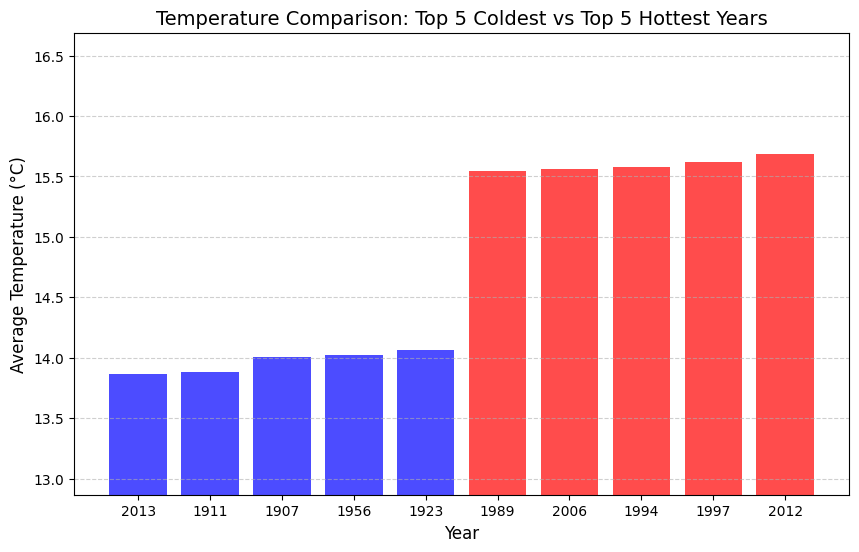

In [67]:
# 3️⃣ Plot Bar Chart showing the temperature difference between hottest and coldest
# Combine and sort the extreme years for a clean chart
extreme_years = pd.concat([top_5_coldest, top_5_hottest]).sort_values('AverageTemperature')

plt.figure(figsize=(10, 6))

# Set colors based on whether it's in the hottest or coldest group
colors = ['blue' if temp in top_5_coldest['AverageTemperature'].values else 'red' 
          for temp in extreme_years['AverageTemperature']]

# Create the bar chart
plt.bar(extreme_years['Year'].astype(str), extreme_years['AverageTemperature'], color=colors, alpha=0.7)

# Customise the chart
plt.title('Temperature Comparison: Top 5 Coldest vs Top 5 Hottest Years', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)

# Adjust y-axis to emphasize the difference (start slightly below the minimum)
min_temp = extreme_years['AverageTemperature'].min()
plt.ylim(min_temp - 1, extreme_years['AverageTemperature'].max() + 1)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()

### 🟣 Task 4: Investigate Correlation with CO₂ Emissions

#### 📂 1️⃣ **Download the CO₂ Emissions Dataset:**  
👉 [OWID CO₂ Data](https://github.com/owid/co2-data) (`owid-co2-data.csv`)

#### 🗂️ 2️⃣ **Load and Preprocess the Data:**  
- 📑 Read the CO₂ dataset into a Pandas DataFrame.  
- 📑 Select relevant columns: `year`, `country`, and `co2`.  
- 🎯 Filter for the same country used in your temperature analysis.  


#### 🔗 3️⃣ **Merge Temperature Data with CO₂ Data:**  
- 🧹	Merge both datasets based on year and country.
- 🧹 Handle any missing values.  


#### 📊 4️⃣ **Create a Scatter Plot:**
-	📈 Plot CO₂ emissions vs. average temperature for the selected country.
-	📈 Label the axes and add a title.

#### 📈 5️⃣ **Fit a Linear Regression Line:**  
- 🟦 Use `seaborn`'s `regplot` to fit a regression line.  
-	Interpret the trend: Does CO₂ emission increase correlate with rising temperatures?

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ & 2️⃣ Load and Preprocess the Data
# Read the CO2 dataset (assumes the file is in your working directory)
co2_df = pd.read_csv('owid-co2-data.csv')

# Select relevant columns and filter for Argentina
co2_df = co2_df[['year', 'country', 'co2']]
co2_argentina = co2_df[co2_df['country'] == 'Argentina'].copy()

# Rename 'year' to 'Year' so it matches our temperature dataframe for merging
co2_argentina = co2_argentina.rename(columns={'year': 'Year', 'country': 'Country'})

# 3️⃣ Merge Temperature Data with CO₂ Data
# Merge using an inner join on 'Year'
merged_data = pd.merge(yearly_data, co2_argentina, on='Year', how='inner')

# Handle missing values by dropping any rows where we lack either CO2 or Temperature data
#merged_data = merged_data.dropna(subset=['co2', 'AverageTemperature'])

# Display the first few rows to verify the merge
merged_data.head()
merged_data

,Year,AverageTemperature,10_Year_Rolling_Avg,Country,co2
0,1900,14.807250,NaN,Argentina,2.026
1,1901,14.809333,NaN,Argentina,2.408
2,1902,14.621167,NaN,Argentina,2.555
3,1903,14.376083,NaN,Argentina,2.923
4,1904,14.432333,NaN,Argentina,3.739
...,...,...,...,...,...
109,2009,15.534417,15.257758,Argentina,178.378
110,2010,15.078833,15.290592,Argentina,186.121
111,2011,15.339667,15.287517,Argentina,189.884
112,2012,15.689000,15.338042,Argentina,191.715


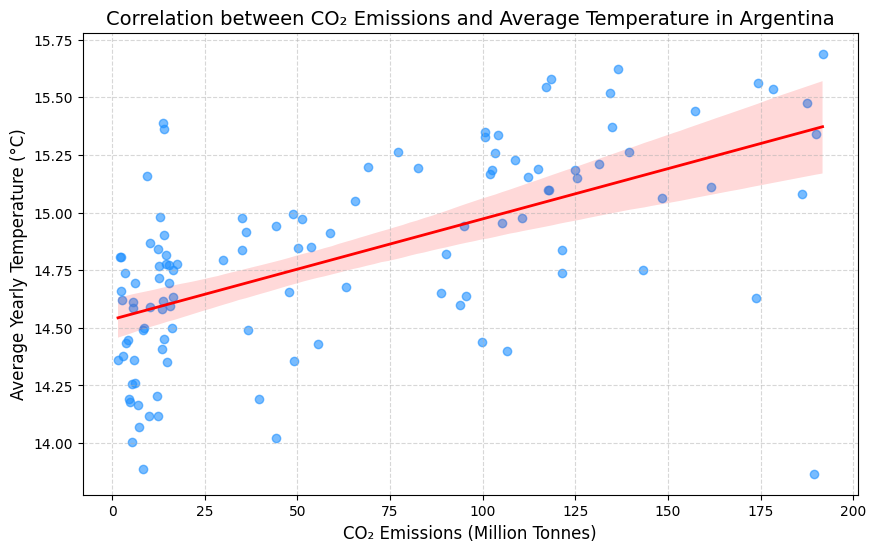

In [69]:
# 4️⃣ & 5️⃣ Create a Scatter Plot and Fit a Linear Regression Line
plt.figure(figsize=(10, 6))

# Use seaborn's regplot to create the scatter plot AND the regression line
sns.regplot(
    data=merged_data, 
    x='co2', 
    y='AverageTemperature',
    scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'}, # Styling the scatter points
    line_kws={'color': 'red', 'linewidth': 2}          # Styling the regression line
)

# Customise the chart with labels and a title
plt.title('Correlation between CO₂ Emissions and Average Temperature in Argentina', fontsize=14)
plt.xlabel('CO₂ Emissions (Million Tonnes)', fontsize=12)
plt.ylabel('Average Yearly Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot
plt.show()